In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# FIX: n_redundant=0 add kiya gaya hai
X, y = make_classification(
    n_samples=100,
    n_features=4,
    n_informative=3,
    n_redundant=0,  # Ab error nahi aayega kyunki 3 + 0 < 4
    n_classes=2,
    random_state=42,
)

# Baki ka code bilkul same rahega
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Predictions on Test Data:", predictions)

accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Predictions on Test Data: [0 1 1 0 1 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1]
Model Accuracy: 90.00%


--- Accuracy Comparison ---
Gini Tree Accuracy:    93.33%
Entropy Tree Accuracy: 93.33%



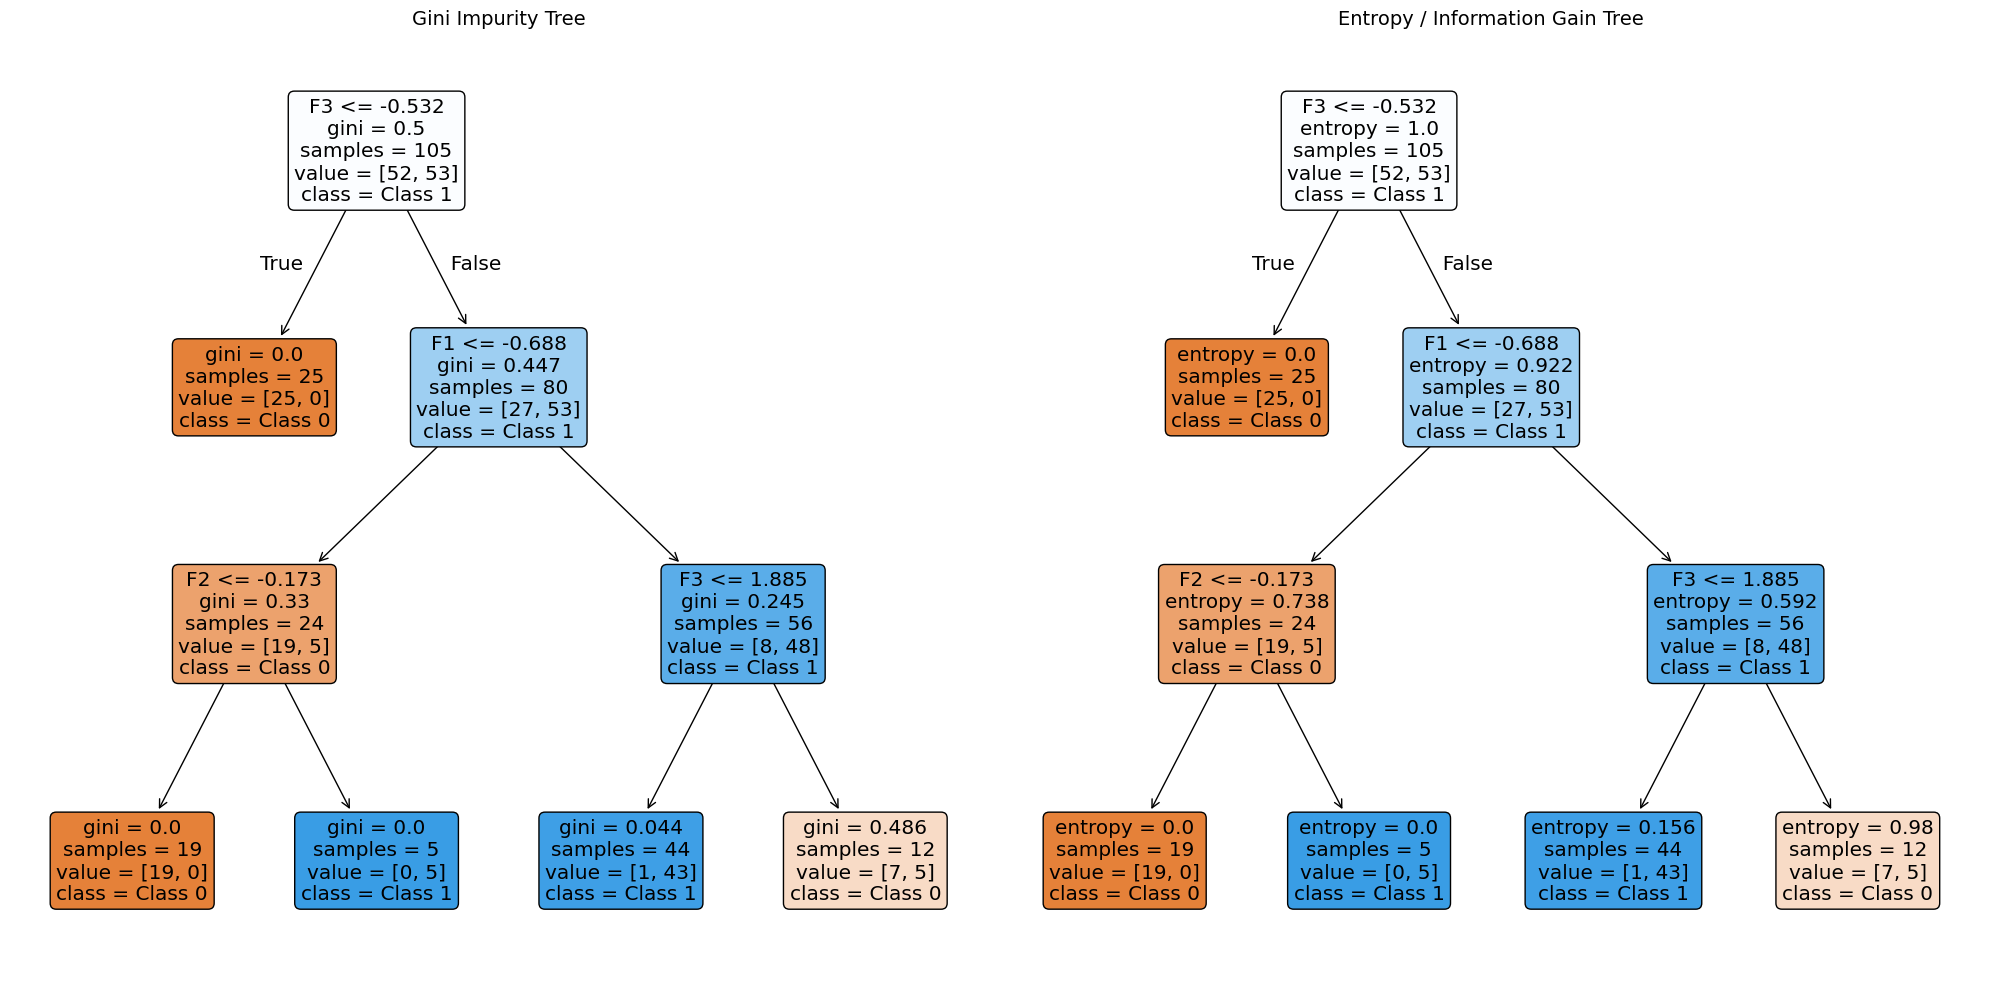

In [4]:
# Topic 104 | Decision Trees - Data Splitting & Feature Selection - Part I
# Topic 105 | Decision Trees - Data Splitting & Feature Selection - Part II

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Dataset generate karein
X, y = make_classification(
    n_samples=150,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

# 2. Data ko Train aur Test sets mein split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --------------------------------------------------
# MODEL 1: Gini Impurity (Part II ka concept)
# --------------------------------------------------
gini_tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
gini_tree.fit(X_train, y_train)
gini_accuracy = gini_tree.score(X_test, y_test)

# --------------------------------------------------
# MODEL 2: Entropy / Information Gain (Part I ka concept)
# --------------------------------------------------
entropy_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=3, random_state=42
)
entropy_tree.fit(X_train, y_train)
entropy_accuracy = entropy_tree.score(X_test, y_test)

# 3. Dono ki Accuracy Print Karein
print("--- Accuracy Comparison ---")
print(f"Gini Tree Accuracy:    {gini_accuracy * 100:.2f}%")
print(f"Entropy Tree Accuracy: {entropy_accuracy * 100:.2f}%\n")

# 4. Dono Trees ko side-by-side plot karein taake splits ka farq nazar aaye
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

# Gini Tree Plot
plot_tree(
    gini_tree,
    filled=True,
    feature_names=["F1", "F2", "F3", "F4"],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    ax=axes[0],
)
axes[0].set_title("Gini Impurity Tree", fontsize=14)

# Entropy Tree Plot
plot_tree(
    entropy_tree,
    filled=True,
    feature_names=["F1", "F2", "F3", "F4"],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    ax=axes[1],
)
axes[1].set_title("Entropy / Information Gain Tree", fontsize=14)

plt.tight_layout()
plt.show()

--- MODEL 1: Overfitted Tree (Unlimited Depth) ---
Training Accuracy: 100.00%
Testing Accuracy:  85.56%
Actual Tree Depth: 11

--- MODEL 2: Controlled Tree (max_depth=4) ---
Training Accuracy: 91.43%
Testing Accuracy:  86.67%
Actual Tree Depth: 4



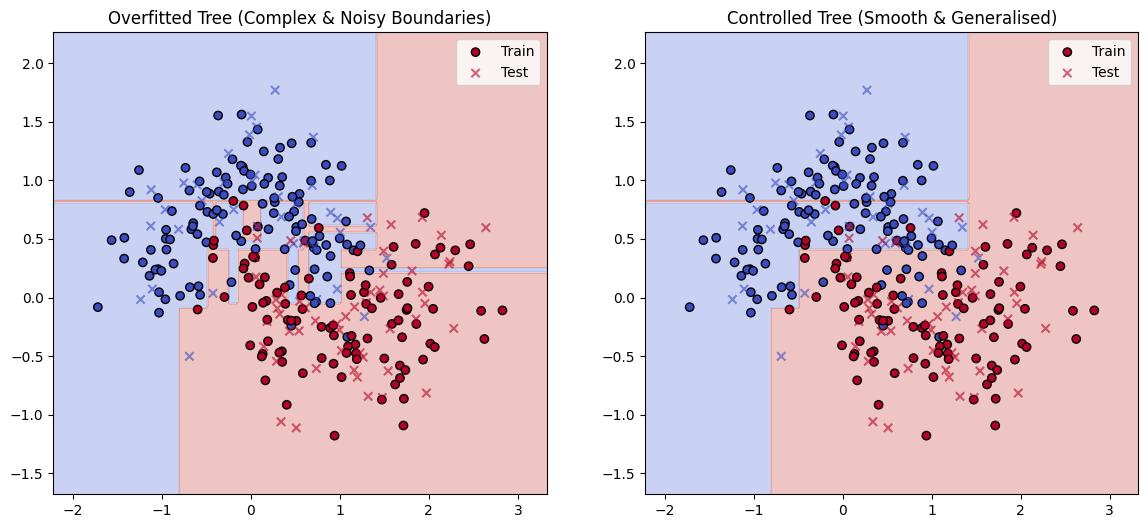

In [5]:
# Topic 106 | Decision Trees - Tree Depth & Overfitting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Ek complex non-linear dataset generate karein (Moons Dataset)
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Data ko Train aur Test sets mein split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------------
# MODEL 1: Overfitted Tree (No depth limit - default)
# ------------------------------------------------------------------
overfitted_model = DecisionTreeClassifier(random_state=42)  # max_depth=None
overfitted_model.fit(X_train, y_train)

train_acc_overfit = overfitted_model.score(X_train, y_train)
test_acc_overfit = overfitted_model.score(X_test, y_test)

# ------------------------------------------------------------------
# MODEL 2: Controlled/Regularized Tree (With max_depth)
# ------------------------------------------------------------------
controlled_model = DecisionTreeClassifier(max_depth=4, random_state=42)
controlled_model.fit(X_train, y_train)

train_acc_control = controlled_model.score(X_train, y_train)
test_acc_control = controlled_model.score(X_test, y_test)

# 2. Results Print Karein
print("--- MODEL 1: Overfitted Tree (Unlimited Depth) ---")
print(f"Training Accuracy: {train_acc_overfit * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc_overfit * 100:.2f}%")
print(f"Actual Tree Depth: {overfitted_model.get_depth()}\n")

print("--- MODEL 2: Controlled Tree (max_depth=4) ---")
print(f"Training Accuracy: {train_acc_control * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc_control * 100:.2f}%")
print(f"Actual Tree Depth: {controlled_model.get_depth()}\n")


# 3. Decision Boundaries Plot Karne Ka Function (Visual Proof)
def plot_boundaries(model, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        cmap="coolwarm",
        edgecolors="k",
        label="Train",
    )
    ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap="coolwarm",
        marker="x",
        alpha=0.6,
        label="Test",
    )
    ax.set_title(title)
    ax.legend()


# Plots Display Karein
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundaries(
    overfitted_model, axes[0], "Overfitted Tree (Complex & Noisy Boundaries)"
)
plot_boundaries(
    controlled_model, axes[1], "Controlled Tree (Smooth & Generalised)"
)
plt.show()

Total unique alpha values found: 14
Best Alpha Value for Pruning: 0.0214

--- Accuracy Comparison ---
Unpruned Tree (Alpha=0) Test Accuracy: 100.00%
Pruned Tree (Best Alpha) Test Accuracy:  90.00%
Pruned Tree Depth: 5


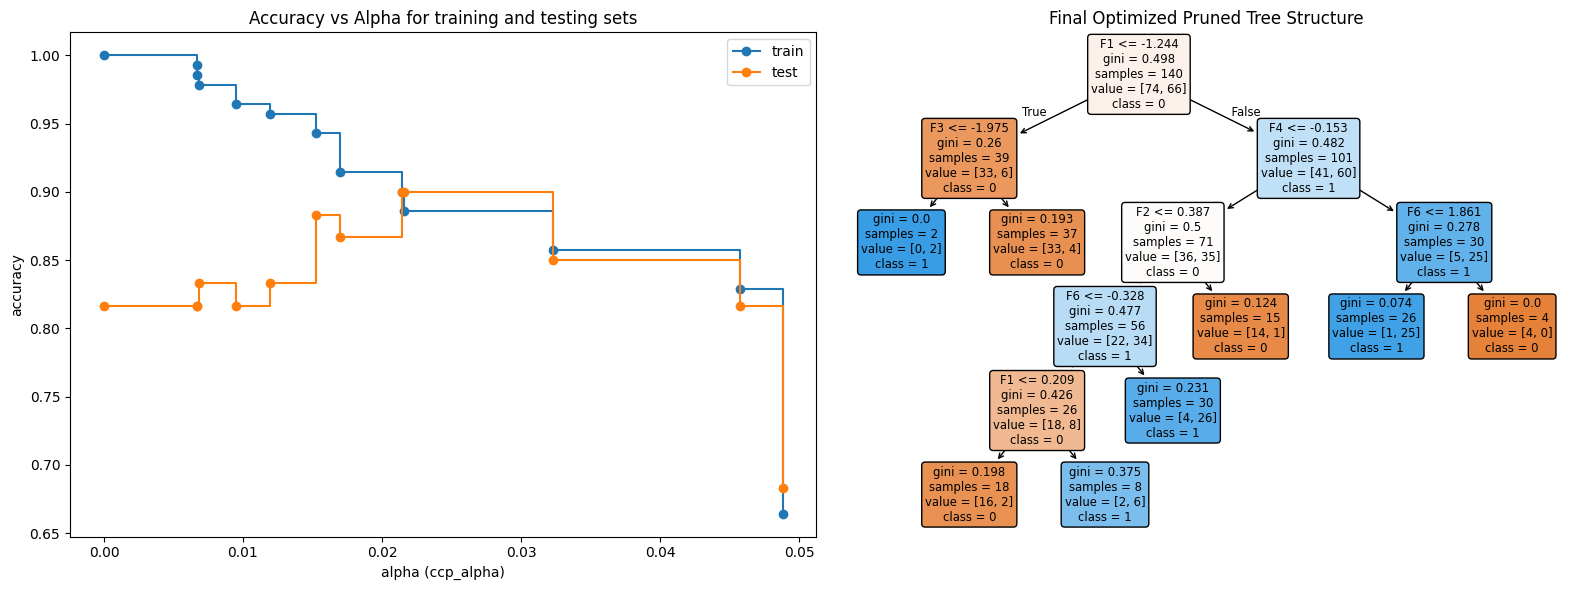

In [6]:
#Topic 107 | Decision Trees - Pruning Techniques
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Ek bada aur noisy dataset generate karein
X, y = make_classification(
    n_samples=200,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    random_state=42,
)

# Data split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------------
# STEP 1: Poora tree grow karein aur effective alphas nikalyein
# ------------------------------------------------------------------
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Total unique alpha values found: {len(ccp_alphas)}")

# ------------------------------------------------------------------
# STEP 2: Har alpha par ek tree train karein aur accuracy check karein
# ------------------------------------------------------------------
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs = clfs + [clf]

# Training aur Testing scores nikalyein (akhri alpha ko chorr kar kyunki woh pure tree ko khatam kar deta hai)
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# ------------------------------------------------------------------
# STEP 3: Best Alpha select karein (Jahan Test Score sabse zyada ho)
# ------------------------------------------------------------------
best_clf_idx = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[best_clf_idx]
print(f"Best Alpha Value for Pruning: {best_alpha:.4f}\n")

# ------------------------------------------------------------------
# STEP 4: Best Alpha ke sath Final Pruned Tree banayein
# ------------------------------------------------------------------
pruned_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_model.fit(X_train, y_train)

print("--- Accuracy Comparison ---")
print(f"Unpruned Tree (Alpha=0) Test Accuracy: {train_scores[0] * 100:.2f}%")
print(
    f"Pruned Tree (Best Alpha) Test Accuracy:  {pruned_model.score(X_test, y_test) * 100:.2f}%"
)
print(f"Pruned Tree Depth: {pruned_model.get_depth()}")

# ------------------------------------------------------------------
# STEP 5: Visualizing Alpha vs Accuracy & Final Tree
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Alpha vs Accuracy
ax[0].plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax[0].plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax[0].set_xlabel("alpha (ccp_alpha)")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Accuracy vs Alpha for training and testing sets")
ax[0].legend()

# Plot 2: Final Pruned Tree Structure
plot_tree(
    pruned_model,
    filled=True,
    feature_names=[f"F{i}" for i in range(1, 7)],
    class_names=["0", "1"],
    rounded=True,
    ax=ax[1],
)
ax[1].set_title("Final Optimized Pruned Tree Structure")

plt.tight_layout()
plt.show()

--- Hyperparameter Tuning Results ---
Best Parameters Found: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 93.85%

--- Model Evaluation on Test Data ---
Test Set Accuracy: 93.86%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



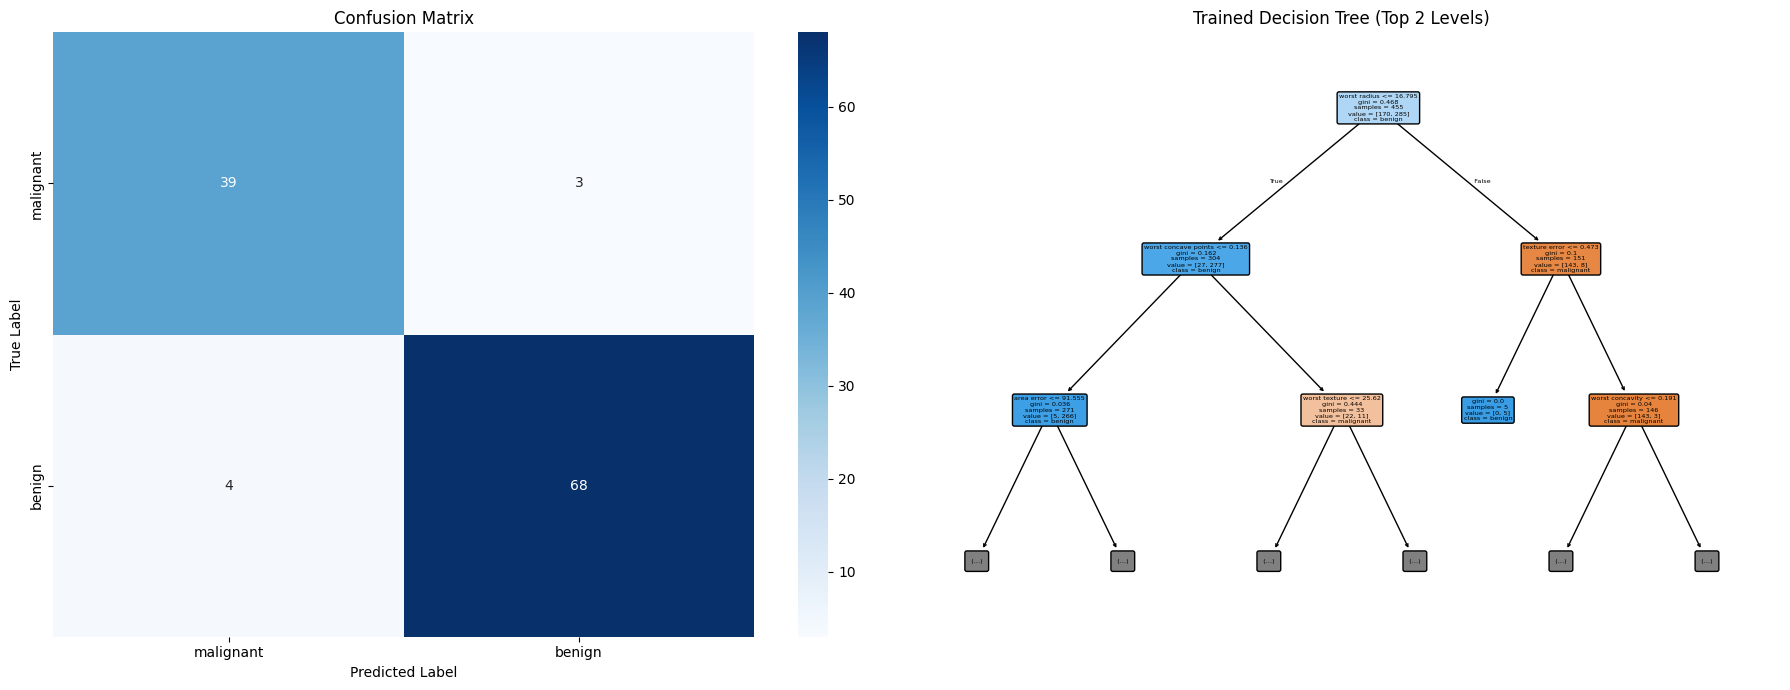

In [7]:
# Topic 108 | Decision Trees - Implementation with Scikit-Learn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Real Dataset Load karein (Breast Cancer Dataset - Binary Classification)
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

# 2. Data ko Train aur Test Sets mein split karein (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Hyperparameters ki Grid define karein
# Hum automatically best combination dhoondenge
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

# 4. GridSearchCV ka use karte hue Best Model dhoondyein
# cv=5 ka matlab hai 5-Fold Cross Validation
base_tree = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=base_tree, param_grid=param_grid, cv=5, n_jobs=-1, scoring="accuracy"
)
grid_search.fit(X_train, y_train)

# Best Parameters print karein
print("--- Hyperparameter Tuning Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%\n")

# 5. Best Model ko select karein
best_model = grid_search.best_estimator_

# 6. Test Data par Predictions karein
y_pred = best_model.predict(X_test)

# 7. Model Evaluation Metrics
print("--- Model Evaluation on Test Data ---")
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 8. Visualizations (Confusion Matrix & Tree Structure)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot 2: Trained Tree Structure (Sirf top layers tak restrict kiya hai visualization ke liye)
plot_tree(
    best_model,
    max_depth=2,  # Visualization clear rakhne ke liye sirf 2 levels dikhaye hain
    filled=True,
    feature_names=feature_names,
    class_names=class_names,
    rounded=True,
    ax=axes[1],
)
axes[1].set_title("Trained Decision Tree (Top 2 Levels)")

plt.tight_layout()
plt.show()

=== SINGLE DECISION TREE ===
Training Accuracy: 100.00%
Testing Accuracy:  80.00%

=== RANDOM FOREST FOREST ===
Training Accuracy: 100.00%
Testing Accuracy:  88.67%



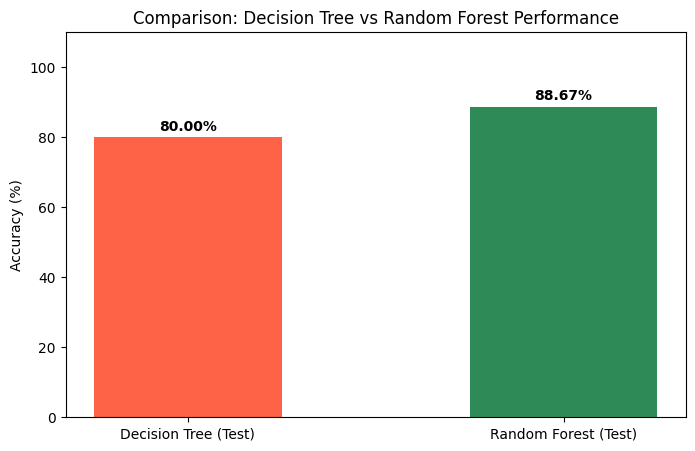

In [8]:
# Topic 109 | Introduction to Random Forest
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Ek complex dataset generate karein
X, y = make_classification(
    n_samples=500,
    n_features=15,
    n_informative=10,
    n_redundant=5,
    random_state=42,
)

# Train aur Test sets mein split karein
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------------
# MODEL 1: Single Decision Tree
# ------------------------------------------------------------------
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_train_acc = tree_model.score(X_train, y_train)
tree_test_acc = tree_model.score(X_test, y_test)

# ------------------------------------------------------------------
# MODEL 2: Random Forest Classifier (Ensemble)
# ------------------------------------------------------------------
# n_estimators=100 ka matlab hai hum 100 decision trees ka forest bana rahe hain
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = rf_model.score(X_test, y_test)

# 2. Performance Comparison Print Karein
print("=== SINGLE DECISION TREE ===")
print(f"Training Accuracy: {tree_train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {tree_test_acc * 100:.2f}%\n")

print("=== RANDOM FOREST FOREST ===")
print(f"Training Accuracy: {rf_train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {rf_test_acc * 100:.2f}%\n")

# 3. Bar Plot for Visual Comparison
models = ["Decision Tree (Test)", "Random Forest (Test)"]
accuracies = [tree_test_acc * 100, rf_test_acc * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=["tomato", "seagreen"], width=0.5)
plt.ylabel("Accuracy (%)")
plt.title("Comparison: Decision Tree vs Random Forest Performance")

# Bars ke upar numbers display karne ke liye
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f"{yval:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylim(0, 110)
plt.show()

In [9]:
# Topic 110 | Random Forest - How It Works - Part I
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# 1. Ek chota dataset generate karein (100 samples, 6 features)
X, y = make_classification(
    n_samples=100, n_features=6, n_informative=4, random_state=42
)

# 2. Random Forest train karein (bootstrap=True lazmi hai row sampling ke liye)
# max_features='sqrt' ka matlab hai har split par takreeban sqrt(6) ~ 2 features select honge
rf = RandomForestClassifier(
    n_estimators=3, bootstrap=True, max_features="sqrt", random_state=42
)
rf.fit(X, y)

print("--- Random Forest Internal Inspection ---")
# Check karein ki har tree ka sample configuration aur features alag hain ya nahi
for idx, tree in enumerate(rf.estimators_):
    print(f"\nTree {idx + 1}:")
    print(f" - Tree Depth: {tree.get_depth()}")
    print(f" - Number of Nodes: {tree.tree_.node_count}")

    # Dekhte hain is tree ne splitting ke liye kaunse features use kiye
    features_used = set(tree.tree_.feature)
    # -2 internally standard notation hai leaf node ke liye, usay nikal dete hain
    features_used.discard(-2)
    print(f" - Distinct Feature Indices used for splitting: {list(features_used)}")



--- Random Forest Internal Inspection ---

Tree 1:
 - Tree Depth: 6
 - Number of Nodes: 27
 - Distinct Feature Indices used for splitting: [np.int64(0), np.int64(1), np.int64(3), np.int64(4)]

Tree 2:
 - Tree Depth: 10
 - Number of Nodes: 43
 - Distinct Feature Indices used for splitting: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Tree 3:
 - Tree Depth: 8
 - Number of Nodes: 35
 - Distinct Feature Indices used for splitting: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


OOB Internal Validation Score: 93.33%
Final Test Set Accuracy (After Voting): 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



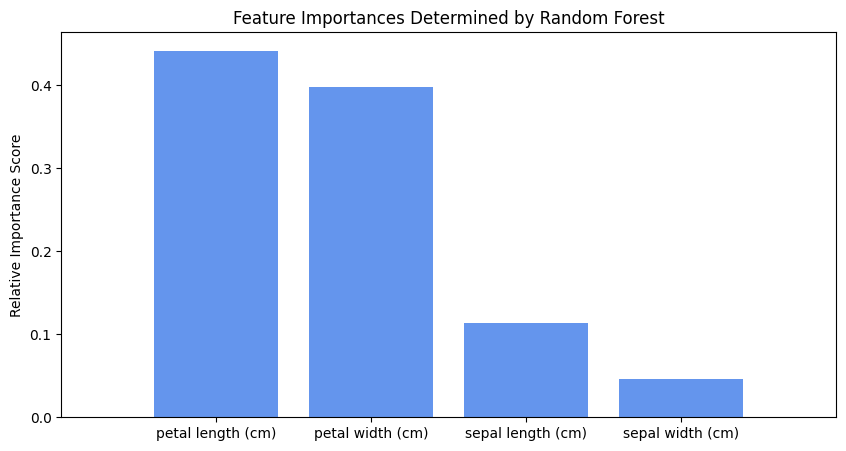

In [10]:
# Topic 111 | Random Forest - How It Works - Part II
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# 1. Dataset load karein
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Random Forest Classifier initialize karein
# oob_score=True set karne se hum bina test data ke bhi model ki quality check kar sakte hain
rf_complete = RandomForestClassifier(
    n_estimators=150,
    max_features="sqrt",
    oob_score=True,  # Part I ka concept: Out-of-Bag Validation
    random_state=42,
    n_jobs=-1,  # Part II ka concept: Parallel Processing
)

# 3. Model train karein
rf_complete.fit(X_train, y_train)

# 4. Out-of-Bag (OOB) Score print karein
print(f"OOB Internal Validation Score: {rf_complete.oob_score_ * 100:.2f}%")

# 5. Predictions on Test Data (Internal Aggregation/Voting occurs here)
y_pred = rf_complete.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"Final Test Set Accuracy (After Voting): {test_acc * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Feature Importance Matrix (Random Forest ka aik aur bara faida)
# Yeh dikhata hai ki pure forest mein kis feature ko splits ke liye sabse zyada value mili
importances = rf_complete.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances Determined by Random Forest")
plt.bar(
    range(X.shape[1]), importances[indices], color="cornflowerblue", align="center"
)
plt.xticks(range(X.shape[1]), [iris.feature_names[i] for i in indices])
plt.xlim([-1, X.shape[1]])
plt.ylabel("Relative Importance Score")
plt.show()

--- Out-of-Bag (OOB) Results ---
OOB R^2 Score: 0.4253
OOB Performance: 42.53% (Bina data split kiye test score)

--- Feature Importance Values ---
Feature  Importance
     s5    0.315252
    bmi    0.273830
     bp    0.092363
     s6    0.071979
    age    0.057745
     s2    0.056136
     s3    0.050602
     s1    0.045364
     s4    0.024970
    sex    0.011760


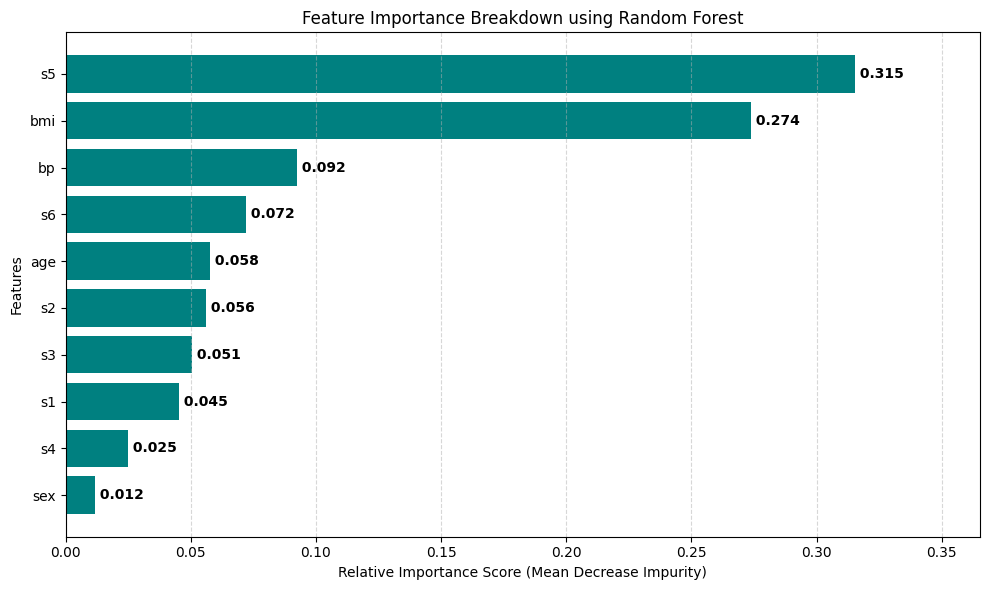

In [11]:
# Topic 112 | Random Forest - Feature Importance & Out-of-Bag Error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor

# 1. Dataset load karein (Diabetes Dataset - Regression Task)
# Is mein hum predict karenge ki mareez ki bimari kis hadd tak barh sakti hai
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# 2. Random Forest Regressor train karein
# NOTE: OOB Score check karne ke liye oob_score=True likhna LAZMI hai
rf_model = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,  # OOB Evaluation active karne ke liye
    random_state=42,
    n_jobs=-1,
)

# Hum pure data par fit kar rahe hain kyunki OOB khud hi validation handles karta hai
rf_model.fit(X, y)

# 3. Out-of-Bag (OOB) Score & Error nikalyein
# Regression mein OOB Score R^2 (Coefficient of Determination) hota hai
oob_r2_score = rf_model.oob_score_
print("--- Out-of-Bag (OOB) Results ---")
print(f"OOB R^2 Score: {oob_r2_score:.4f}")
print(f"OOB Performance: {oob_r2_score * 100:.2f}% (Bina data split kiye test score)\n")

# 4. Feature Importances Extract karein
importances = rf_model.feature_importances_

# Dataframe banayein taake sorting aur plotting aasan ho
df_importance = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=True)

print("--- Feature Importance Values ---")
print(df_importance.sort_values(by="Importance", ascending=False).to_string(index=False))

# 5. Feature Importance Ka Horizontal Bar Plot Banayein
plt.figure(figsize=(10, 6))
plt.barh(df_importance["Feature"], df_importance["Importance"], color="teal")
plt.xlabel("Relative Importance Score (Mean Decrease Impurity)")
plt.ylabel("Features")
plt.title("Feature Importance Breakdown using Random Forest")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Har bar ke agay exact value display karne ke liye
for index, value in enumerate(df_importance["Importance"]):
    plt.text(value, index, f" {value:.3f}", va="center", fontweight="bold")

plt.xlim(0, max(importances) + 0.05)
plt.tight_layout()
plt.show()